In [5]:
import torch
import gym
from gym import spaces
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple
from torch.utils.tensorboard import SummaryWriter
import argparse
from replay_buffer import ReplayBuffer
from maddpg import MADDPG
import copy
from PrioritizedReplayBuffer import PrioritizedReplayBuffer # <-- 导入新的
# NUM_STEP = 96*1
# FUTURE_PRICE = 6
# NUM_AGENT = 3# 假设有3个智能体
# BATTERY_CAPACITY = 2.0
# MAX_CHARGE_RATE = 0.2

In [6]:
class EnergyStorageEnv(gym.Env):
    def __init__(self, num_agents, episode_length, future_price, battery_capacity, max_charge_rate):
        # --- 核心属性 ---
        self.num_agents = num_agents
        self.episode_length = episode_length
        self.future_price = future_price
        
        # [MODIFIED] 兼容Runner: Runner通过 env.n 获取智能体数量
        self.n = self.num_agents 
        
        # --- 储能相关参数 ---
        self.battery_capacity = battery_capacity
        self.max_charge_rate = max_charge_rate
        self.efficiency = 1.0  # 为调试方便设为1
        self.init_soc = 0.05
        
        # --- 数据加载与处理 ---
        # 假设数据文件在固定路径
        data_path = Path.cwd().parent / "data" / "opsd_building.csv"
        self.raw_data = self._load_data(data_path)
        self.normalization_params = self._calculate_normalization_params()
        
        # 为回合特定的价格归一化参数添加初始化
        self.episode_price_mean = 0
        self.episode_price_std = 1

        # [MODIFIED] 兼容Runner: observation_space 和 action_space 必须是列表
        self.observation_space = self._create_observation_space()
        self.action_space = self._create_action_space()

        # --- 状态与历史记录 ---
        self.current_step = 0
        self.battery_soc = {}
        self.load_profiles = {}
        
        # 初始化状态
        self.reset()

    def _create_observation_space(self) -> List[spaces.Box]:
        """创建包含完整电价序列的观察空间"""
        # obs_shape = (4 + self.episode_length,)
        obs_shape = (5 + 6,)
        single_obs_space = spaces.Box(low=-np.inf, high=np.inf, shape=obs_shape, dtype=np.float32)
        # [MODIFIED] 兼容Runner: 返回列表
        return [single_obs_space for _ in range(self.num_agents)]

    def _create_action_space(self) -> List[spaces.Box]:
        """创建动作空间"""
        single_action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        # [MODIFIED] 兼容Runner: 返回列表。Runner的动作范围是[-1, 1]
        return [single_action_space for _ in range(self.num_agents)]
    
    def _load_data(self, data_path: str) -> pd.DataFrame:
        """from csv file"""
        try:
            data = pd.read_csv(data_path)
            # print("Data loaded successfully.")
            return data
        except Exception as e:
            raise ValueError(f"Unable to load data file: {e}")
        
    def _calculate_normalization_params(self) -> Dict[str, float]:
        """计算标准化所需参数"""
        params = {}
        prices = self.raw_data.iloc[:, -1].values
        params['price_mean'] = np.mean(prices)
        params['price_std'] = np.std(prices)
        
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        all_loads = self.raw_data[load_cols].values.flatten()
        params['load_mean'] = np.mean(all_loads)
        params['load_std'] = np.std(all_loads)
        return params
    
    def _process_load_data(self) -> Dict[int, pd.DataFrame]:
        """处理负荷数据并为每个agent创建负荷曲线"""
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        num_rows = self.raw_data.shape[0]
        num_days = num_rows // self.episode_length

        # 确保有足够的数据用于一个回合+未来视野余量
        num_available_episodes = (num_rows - 2 * self.episode_length) // self.episode_length
        if num_available_episodes <= 0:
            raise ValueError("Not enough data in the file to run a single episode with the required future horizon.")
        
        load_data = self.raw_data[load_cols].values
        price_data = self.raw_data.iloc[:, -1].values
        
        load_profiles = {}
        day_idx = np.random.randint(0, num_available_episodes)
        # day_idx = 2
        start = day_idx * self.episode_length + 48 #往后延迟半天，希望能在前面充电，后面放电
        end = start + self.episode_length + self.episode_length 
        
        episode_prices = price_data[start-96:end-96]
        self.episode_price_mean = np.mean(episode_prices)
        self.episode_price_std = np.std(episode_prices)
        if self.episode_price_std == 0:
            self.episode_price_std = 1 # 避免除以零
        
        for agent_id in range(self.num_agents):
            agent_load = (load_data[start:end, agent_id] - self.normalization_params['load_mean']) / self.normalization_params['load_std']
            # 使用回合特定的均值和标准差
            agent_price = (episode_prices - self.episode_price_mean) / self.episode_price_std
            
        # for agent_id in range(self.num_agents):
        #     agent_load = (load_data[start:end, agent_id] - self.normalization_params['load_mean']) / self.normalization_params['load_std']
        #     agent_price = (price_data[start:end] - self.normalization_params['price_mean']) / self.normalization_params['price_std']
            
            df = pd.DataFrame({'load': agent_load, 'price': agent_price})
            load_profiles[agent_id] = df
        return load_profiles
    
    def _get_single_observation(self, agent_id: int) -> np.ndarray:
        """获取包含完整电价序列的观察值"""
        time_sin = np.sin(2 * np.pi * self.current_step / self.episode_length)
        time_cos = np.cos(2 * np.pi * self.current_step / self.episode_length)
        
        current_price = self.load_profiles[agent_id]['price'].iloc[self.current_step]
        current_load = self.load_profiles[agent_id]['load'].iloc[self.current_step]
        current_soc = self.battery_soc[agent_id]
        
        # 获取未来6个点的电价 (由于加载了额外数据，这里不再需要填充)
        future_prices_full = self.load_profiles[agent_id]['price'].values
        start_idx = self.current_step + 1
        end_idx = start_idx + self.future_price
        future_price_slice = future_prices_full[start_idx:end_idx]

        state_vector = np.array([time_sin, time_cos, current_price, current_load, current_soc], dtype=np.float32)
        # 将基础状态和未来电价拼接成最终的观察向量
        obs = np.concatenate([state_vector, future_price_slice.astype(np.float32)])
        return obs
        # return state_vector

    def reset(self) -> List[np.ndarray]:
        """重置环境到初始状态"""
        self.current_step = 0
        self.battery_soc = {agent_id: self.init_soc for agent_id in range(self.num_agents)}
        self.load_profiles = self._process_load_data()
        
        # [MODIFIED] 兼容Runner: 返回列表
        obs_n = [self._get_single_observation(i) for i in range(self.num_agents)]
        return obs_n
    
    def step(self, actions: List[np.ndarray]) -> Tuple[List[np.ndarray], List[float], List[bool], Dict]:
        """执行一个时间步的环境动态"""
        # [MODIFIED] 兼容Runner: 将输入的动作列表转换为字典
        actions_dict = {i: action[0] for i, action in enumerate(actions)}

        current_price_normalized = self.load_profiles[0]['price'].iloc[self.current_step]
        
        rewards = {}
        ess_power = {}

        for agent_id, action_val in actions_dict.items():
            # 动作值在[-1, 1]之间，映射到[-max_rate, max_rate]
            charge_power = action_val * self.max_charge_rate
            
            # 计算SOC变化
            delta_soc = (charge_power * self.efficiency) / self.battery_capacity if charge_power >= 0 else (charge_power / self.efficiency) / self.battery_capacity
            new_soc = self.battery_soc[agent_id] + delta_soc

            # 初始化惩罚项
            action_penalty = 0.0

            # 边界检查和修正
            if new_soc > 0.95:
                charge_power = min(charge_power, ((0.95 - self.battery_soc[agent_id]) * self.battery_capacity) / self.efficiency)
                new_soc = 0.95
                # 如果智能体尝试过度充电，给予惩罚
                if action_val > 0:
                    action_penalty = -5.0
            if new_soc < 0.05:
                charge_power = max(charge_power, -((self.battery_soc[agent_id] - 0.05) * self.battery_capacity * self.efficiency))
                new_soc = 0.05
                # 如果智能体尝试过度放电，给予惩罚
                if action_val < 0:
                    action_penalty = -5.0
                
            self.battery_soc[agent_id] = new_soc
            ess_power[agent_id] = charge_power

            # 计算奖励
            # real_price = current_price_normalized * self.normalization_params['price_std'] + self.normalization_params['price_mean']
            real_price = current_price_normalized * self.episode_price_std + self.episode_price_mean
            cost = ess_power[agent_id] * real_price
            
            # 奖励 = 经济收益 + 行为惩罚
            # 当充电时，经济收益为负；当放电时，经济收益为正
            economic_reward = -cost
            # 如果智能体尝试过度充电或放电，给予惩罚
            rewards[agent_id] = economic_reward + action_penalty

        self.current_step += 1
        
        # 检查episode是否结束
        done = self.current_step >= self.episode_length
        done_n = [done for _ in range(self.num_agents)]

        # 获取下一个观察值
        obs_n = [self._get_single_observation(i) for i in range(self.num_agents)] if not done else [np.zeros(self.observation_space[i].shape) for i in range(self.num_agents)]
        
        # [MODIFIED] 兼容Runner: 将奖励字典转换为列表
        reward_n = [rewards[i] for i in range(self.num_agents)]

        # 将需要记录的内部状态放入info字典
        info = {
            'ess_power': ess_power,
            'soc': self.battery_soc,
            'price': real_price
        }
        return obs_n, reward_n, done_n, info

    def close(self):
        pass

In [7]:
class Runner:   # 定义一个名为 Runner 的类，它封装了整个训练和评估的流程
    def __init__(self, args, env_name, number, seed): # Runner 类的构造函数，用于初始化训练设置
        self.args = args # 保存所有通过 argparse 解析的参数
        self.env_name = env_name
        self.number = number
        self.seed = seed
        # Create env
        env_params = {
            'num_agents': args.num_agents,
            'episode_length': args.episode_limit,
            'future_price': args.future_price,
            'battery_capacity': args.battery_capacity,
            'max_charge_rate': args.max_charge_rate
        }
        self.env = EnergyStorageEnv(**env_params)  # 创建用于训练的环境实例，指定为连续动作空间
        self.env_evaluate = EnergyStorageEnv(**env_params)# 创建一个独立的环境实例用于评估策略
        print("--- Normalization Parameters ---")
        print(f"  Price Mean: {self.env.normalization_params['price_mean']:.4f}")
        print(f"  Price Std: {self.env.normalization_params['price_std']:.4f}")
        print(f"  Load Mean: {self.env.normalization_params['load_mean']:.4f}")
        print(f"  Load Std: {self.env.normalization_params['load_std']:.4f}")
        print("------------------------------")
        self.args.N = self.env.n  # The number of agents
        self.args.obs_dim_n = [self.env.observation_space[i].shape[0] for i in range(self.args.N)]  # obs dimensions of N agents
        self.args.action_dim_n = [self.env.action_space[i].shape[0] for i in range(self.args.N)]  # actions dimensions of N agents
        print("observation_space=", self.env.observation_space)
        print("obs_dim_n={}".format(self.args.obs_dim_n))
        print("action_space=", self.env.action_space)
        print("action_dim_n={}".format(self.args.action_dim_n))

        # Set random seed
        np.random.seed(self.seed)
        torch.manual_seed(self.seed) # 为 PyTorch 设置随机种子，以确保网络初始化和训练过程的可复现性

        # Create N agents
        if self.args.algorithm == "MADDPG":
            print("Algorithm: MADDPG")
            self.agent_n = [MADDPG(args, agent_id) for agent_id in range(args.N)]
        else:
            print("Wrong!!!")

        self.replay_buffer = ReplayBuffer(self.args) # 根据参数创建一个经验回放缓冲区实例
        # self.replay_buffer = PrioritizedReplayBuffer(self.args) # <-- 使用新的
        # Create a tensorboard,# 创建一个 SummaryWriter 实例，用于记录训练日志，日志文件会保存在指定的目录结构下
        self.writer = SummaryWriter(log_dir='runs/{}/{}_env_{}_number_{}_seed_{}'.format(self.args.algorithm, self.args.algorithm, self.env_name, self.number, self.seed))
        self.evaluate_rewards = []  # 初始化一个空列表，用于记录每次评估的平均奖励
        self.episode_rewards = []  # 用于记录每个训练回合的奖励
        self.history = []  # 新增：用于存储每一代的详细历史数据
        self.total_steps = 0

        self.noise_std = self.args.noise_std_init   # 初始化用于动作探索的高斯噪声的标准差

    def run(self, ):
        self.evaluate_policy() # 在正式开始训练前，先对未经训练的初始策略进行一次评估

        episode_num = 0
        while self.total_steps < self.args.max_train_steps:
            obs_n = self.env.reset() # 重置环境，开始一个新的 episode，并获取初始观测
            episode_reward = 0  # 初始化当前训练回合的奖励
            episode_actions_history = [[] for _ in range(self.args.N)]
            episode_soc_history = [[] for _ in range(self.args.N)]
            episode_price_history = []
            for i in range(self.args.N): # 记录初始SOC
                episode_soc_history[i].append(self.env.battery_soc[i])
            for _ in range(self.args.episode_limit):
                # 每个智能体根据自己的局部观测选择动作，并加入噪声以进行探索
                a_n = [agent.choose_action(obs, noise_std=self.noise_std) for agent, obs in zip(self.agent_n, obs_n)]
                # --------------------------!!!注意！！！这里一定要deepcopy，MPE环境会把a_n乘5-------------------------------------------
                obs_next_n, r_n, done_n, info = self.env.step(copy.deepcopy(a_n))# 将动作列表传入环境，执行一步，并获取返回的下一个观测、奖励、完成标志等
                episode_reward += sum(r_n) # 累加当前步所有智能体的奖励

                #-----------------记录-----------------
                episode_price_history.append(info['price'])
                for i in range(self.args.N):
                    episode_actions_history[i].append(info['ess_power'][i])
                    episode_soc_history[i].append(info['soc'][i])

                if episode_num % 20 < 1:
                    print(f"--- Episode: {episode_num + 1}, Step: {self.total_steps} ---")
                    # 打印第一个智能体的观测值、动作和奖励
                    print(f"  Obs (Agent 0): {obs_n[0]}")
                    print(f"  Action (Agent 0): {a_n[0]}")
                    print(f"  Reward (Agent 0): {r_n[0]}")
                    print("-" * 20)

                # Store the transition
                self.replay_buffer.store_transition(obs_n, a_n, r_n, obs_next_n, done_n) # 将这个(s, a, r, s')的转换经验存储到回放缓冲区
                obs_n = obs_next_n # 更新当前观测，为下一步做准备
                self.total_steps += 1

                # Decay noise_std
                if self.args.use_noise_decay: # 如果启用了噪声衰减
                    # 线性衰减噪声标准差，直到达到设定的最小值
                    self.noise_std = self.noise_std - self.args.noise_std_decay if self.noise_std - self.args.noise_std_decay > self.args.noise_std_min else self.args.noise_std_min

                if self.replay_buffer.current_size > self.args.batch_size: # 当缓冲区中的经验数量足够一个批次时
                    # Train each agent individually
                    for agent_id in range(self.args.N): 
                        self.agent_n[agent_id].train(self.replay_buffer, self.agent_n) # 对每个智能体进行一次训练

                # if self.total_steps % self.args.evaluate_freq == 0:  # 每隔一定的步数
                #     self.evaluate_policy() # 就对当前策略进行一次评估

                if all(done_n):
                    break

            episode_num += 1
            self.history.append({
                'actions': episode_actions_history,
                'soc': episode_soc_history,
                'price': episode_price_history
            })
            self.episode_rewards.append(episode_reward)
            avg_reward = np.mean(self.episode_rewards[-100:]) if len(self.episode_rewards) >= 100 else np.mean(self.episode_rewards) # 计算最近100个回合的平均奖励，如果不足100个则计算所有回合的平均奖励
            # 打印每个训练回合的结果
            print(f"Episode: {episode_num}, Total Steps: {self.total_steps}, Reward: {episode_reward:.2f}, Avg Reward: {avg_reward:.2f}")
            # 将训练回合的奖励也记录到 TensorBoard
            self.writer.add_scalar('train_episode_rewards_{}'.format(self.env_name), episode_reward, global_step=self.total_steps)
            self.writer.add_scalar('avg_episode_rewards_{}'.format(self.env_name), avg_reward, global_step=self.total_steps)
        self.env.close()
        self.env_evaluate.close()

    def evaluate_policy(self, ):# 定义评估策略性能的方法
        evaluate_reward = 0
        for _ in range(self.args.evaluate_times): # 运行指定次数的评估 episode，以获得更稳定的结果
            obs_n = self.env_evaluate.reset()        # 重置评估环境
            episode_reward = 0                       # 初始化当前 episode 的奖励
            for _ in range(self.args.episode_limit): # 在单个 episode 内运行
                a_n = [agent.choose_action(obs, noise_std=0) for agent, obs in zip(self.agent_n, obs_n)]  # 评估时动作不加噪声，以测试策略的确定性表现
                obs_next_n, r_n, done_n, _ = self.env_evaluate.step(copy.deepcopy(a_n)) # 在评估环境中执行动作
                episode_reward += r_n[0] # 累加当前步的奖励（这里假设使用第一个智能体的奖励或共享奖励作为代表）
                obs_n = obs_next_n  # 更新观测
                if all(done_n):
                    break
            evaluate_reward += episode_reward

        evaluate_reward = evaluate_reward / self.args.evaluate_times # 计算平均评估奖励
        self.evaluate_rewards.append(evaluate_reward) # 将本次的平均奖励添加到历史记录中

        # 打印当前的训练步数、评估奖励和噪声标准差，并且将评估奖励写入 TensorBoard
        print("total_steps:{} \t evaluate_reward:{} \t noise_std:{}".format(self.total_steps, evaluate_reward, self.noise_std))
        self.writer.add_scalar('evaluate_step_rewards_{}'.format(self.env_name), evaluate_reward, global_step=self.total_steps)
        # 将评估奖励的历史记录保存为 numpy 数组文件
        np.save('./data_train/{}_env_{}_number_{}_seed_{}.npy'.format(self.args.algorithm, self.env_name, self.number, self.seed), np.array(self.evaluate_rewards))
        for agent_id in range(self.args.N):
            self.agent_n[agent_id].save_model(self.env_name, self.args.algorithm, self.number, self.total_steps, agent_id)



In [8]:
if __name__ == '__main__':
    TrainEpisode = 200  # 训练的总回合数
    STEP=96
    parser = argparse.ArgumentParser("Hyperparameters Setting for MADDPG and MATD3 in MPE environment")
    
    
    # --- 环境相关参数 ---
    parser.add_argument("--num_agents", type=int, default=3, help="Number of agents")
    parser.add_argument("--future_price", type=int, default=6, help="Number of future price steps to observe")
    parser.add_argument("--battery_capacity", type=float, default=2.0, help="Capacity of the battery (kWh)")
    parser.add_argument("--max_charge_rate", type=float, default=0.2, help="Max charge/discharge rate of the battery (kW)")

    # --- 训练相关参数 ---
    parser.add_argument("--algorithm", type=str, default="MADDPG", help="MADDPG or MATD3")
    parser.add_argument("--episode_limit", type=int, default=STEP, help="Maximum number of steps per episode")
    parser.add_argument("--max_train_steps", type=int, default=int(TrainEpisode*STEP), help=" Maximum number of training steps")
    parser.add_argument("--batch_size", type=int, default=STEP*10, help="Batch size")
    parser.add_argument("--evaluate_freq", type=float, default=100, help="Evaluate the policy every 'evaluate_freq' steps")
    parser.add_argument("--evaluate_times", type=float, default=3, help="Evaluate times")
    parser.add_argument("--max_action", type=float, default=1.0, help="Max action")

    
    parser.add_argument("--buffer_size", type=int, default=int(1e6), help="The capacity of the replay buffer")
    parser.add_argument("--hidden_dim", type=int, default=256, help="The number of neurons in hidden layers of the neural network")
    parser.add_argument("--noise_std_init", type=float, default=0.2*2, help="The std of Gaussian noise for exploration")
    parser.add_argument("--noise_std_min", type=float, default=0.1*2, help="The std of Gaussian noise for exploration")
    parser.add_argument("--noise_decay_steps", type=float, default=3e5, help="How many steps before the noise_std decays to the minimum")
    parser.add_argument("--use_noise_decay", type=bool, default=True, help="Whether to decay the noise_std")
    parser.add_argument("--lr_a", type=float, default=1e-4, help="Learning rate of actor")
    parser.add_argument("--lr_c", type=float, default=1e-4, help="Learning rate of critic")
    parser.add_argument("--gamma", type=float, default=0.999, help="Discount factor")
    parser.add_argument("--tau", type=float, default=0.01, help="Softly update the target network")
    parser.add_argument("--use_orthogonal_init", type=bool, default=True, help="Orthogonal initialization")
    parser.add_argument("--use_grad_clip", type=bool, default=True, help="Gradient clip")
    parser.add_argument("--policy_update_freq", type=int, default=2, help="The frequency of policy updates")

    args = parser.parse_args(args=[])
    args.noise_std_decay = (args.noise_std_init - args.noise_std_min) / args.noise_decay_steps

    env_name = "EnergyStorage"
    runner = Runner(args, env_name=env_name, number=1, seed=0)
    runner.run()


--- Normalization Parameters ---
  Price Mean: 31.7396
  Price Std: 14.3649
  Load Mean: 0.1090
  Load Std: 0.1309
------------------------------
observation_space= [Box(11,), Box(11,), Box(11,)]
obs_dim_n=[11, 11, 11]
action_space= [Box(1,), Box(1,), Box(1,)]
action_dim_n=[1, 1, 1]
Algorithm: MADDPG
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
------use_orthogonal_init------
total_steps:0 	 evaluate_reward:-28.351946358392322 	 noise_std:0.4
--- Episode: 1, Step: 0 ---
  Obs (Agent 0): [ 0.          1.         -0.47403425  0.09176575  0.05       -0.47403425
 -0.46909505 -0.46909505 -0.46909505 -0.46909505 -0.43863666]
  Action (Agent 0): [-0.51135126]
  Reward (Agent 0): -5.0
--------------------
--- Episode: 1, Step: 1 ---
  Obs (Agent 0): [ 0.06540313  0.99785894 -0.47403425  0.22932647  0.05       -0.46909505
 -0.46909505 -0.46909505 -0.46909505 -0.43863666 -0.43863666

--- Plotting Reward Curve ---


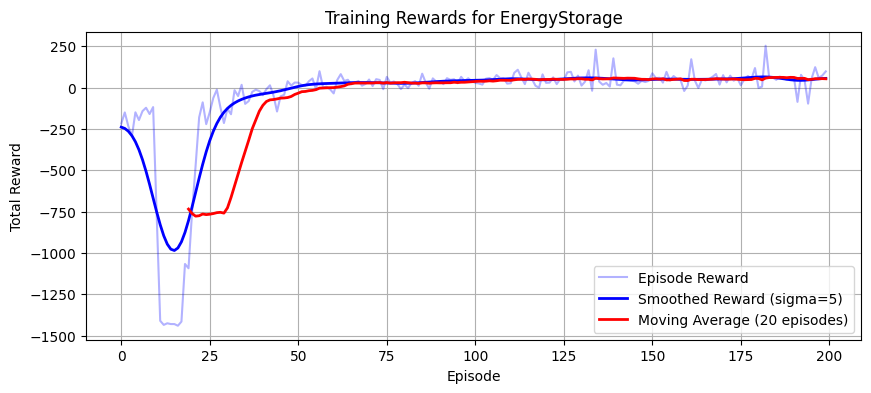


--- Plotting Detailed Results for Episodes: [1, 21, 51, 101, 151, 176, 200] ---


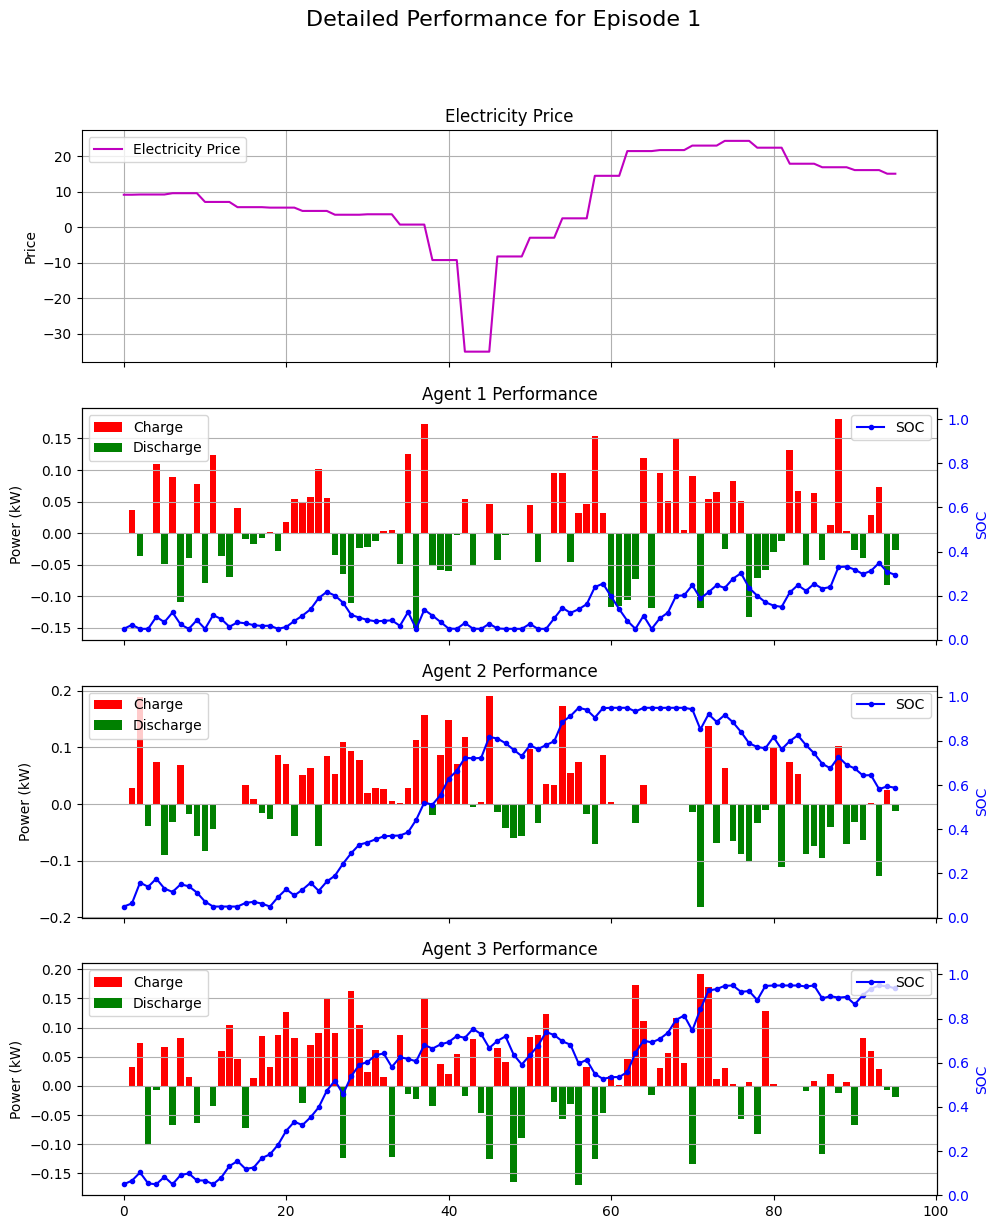

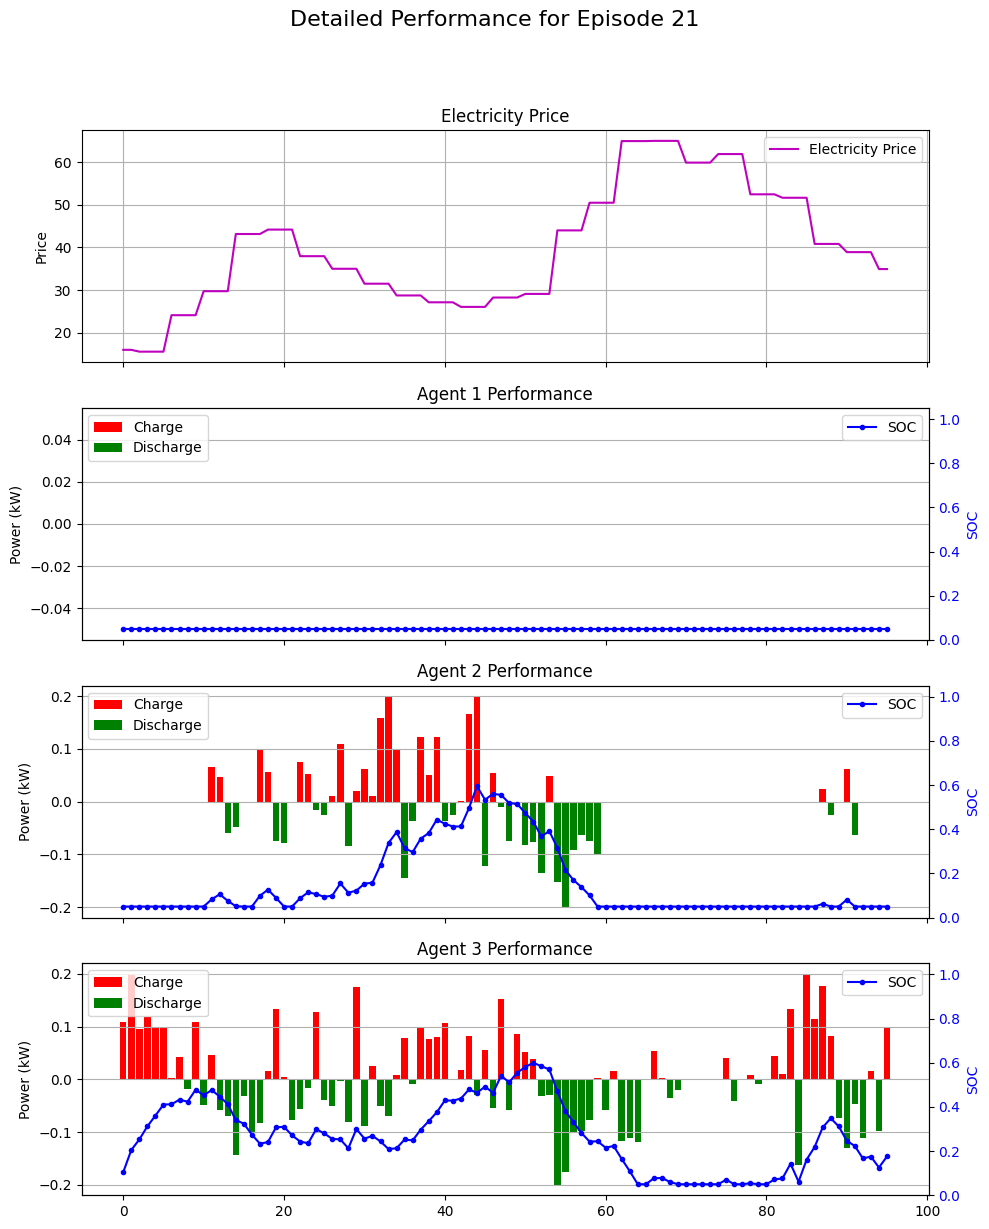

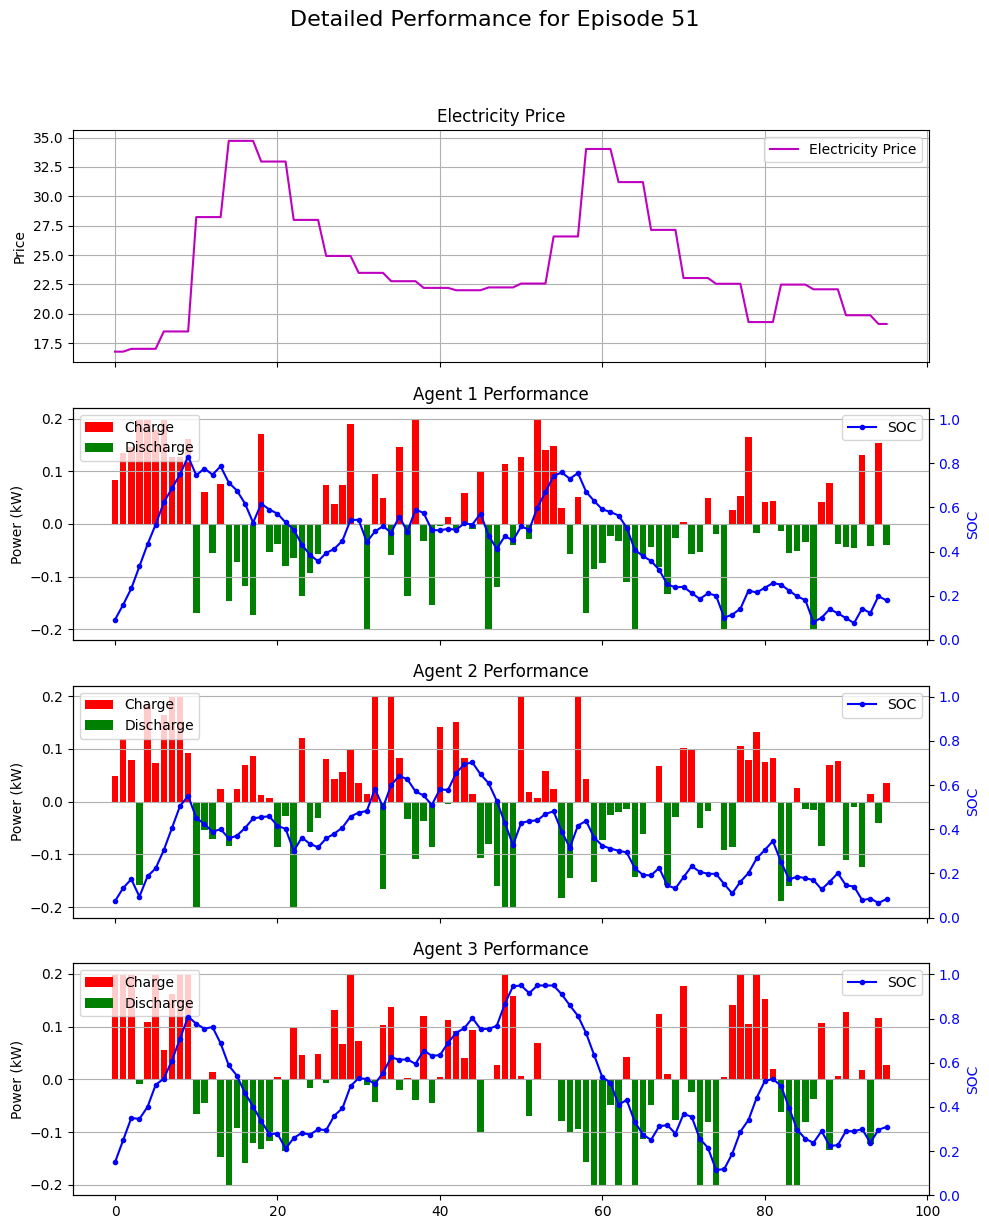

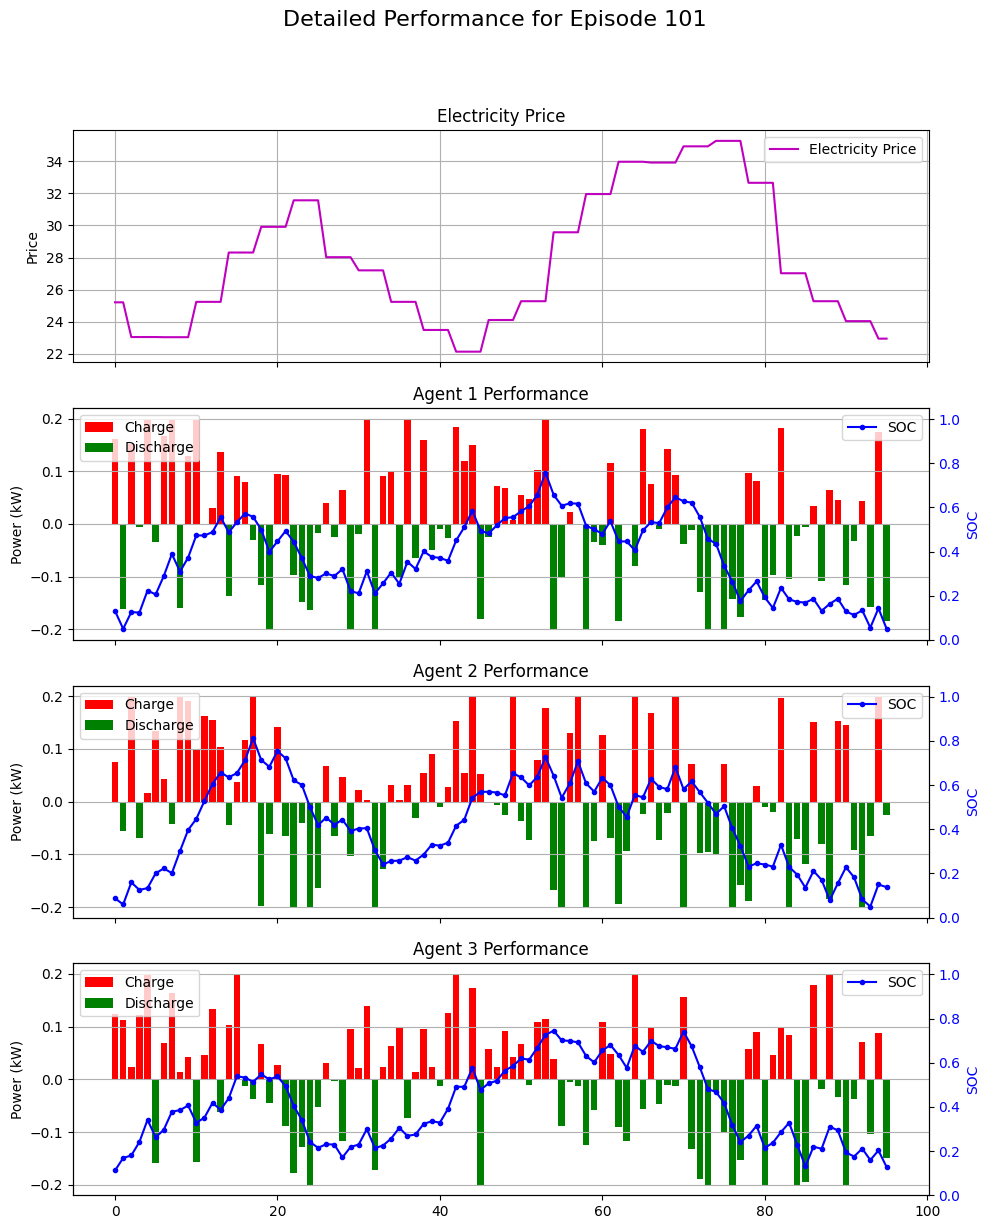

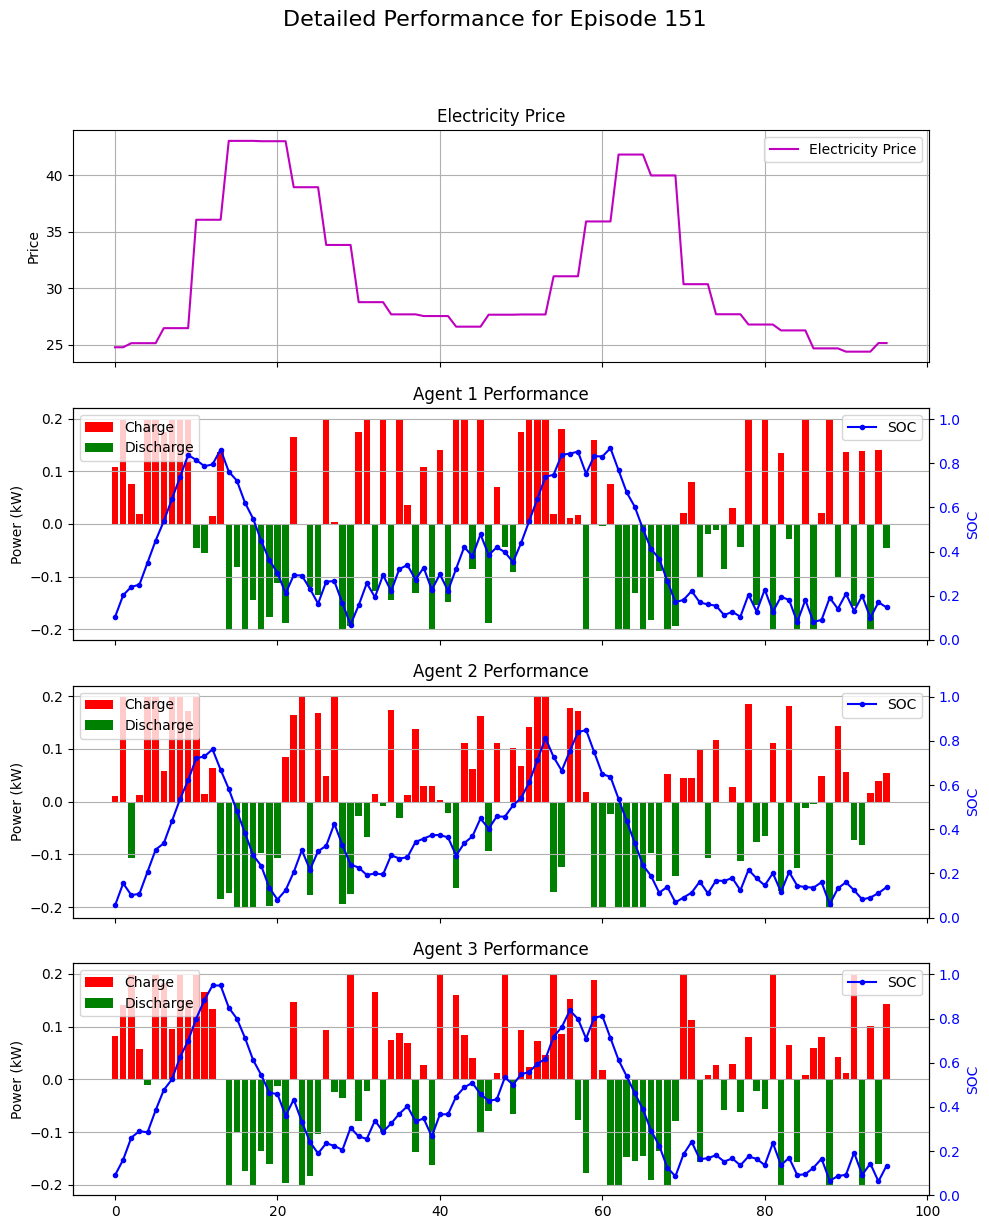

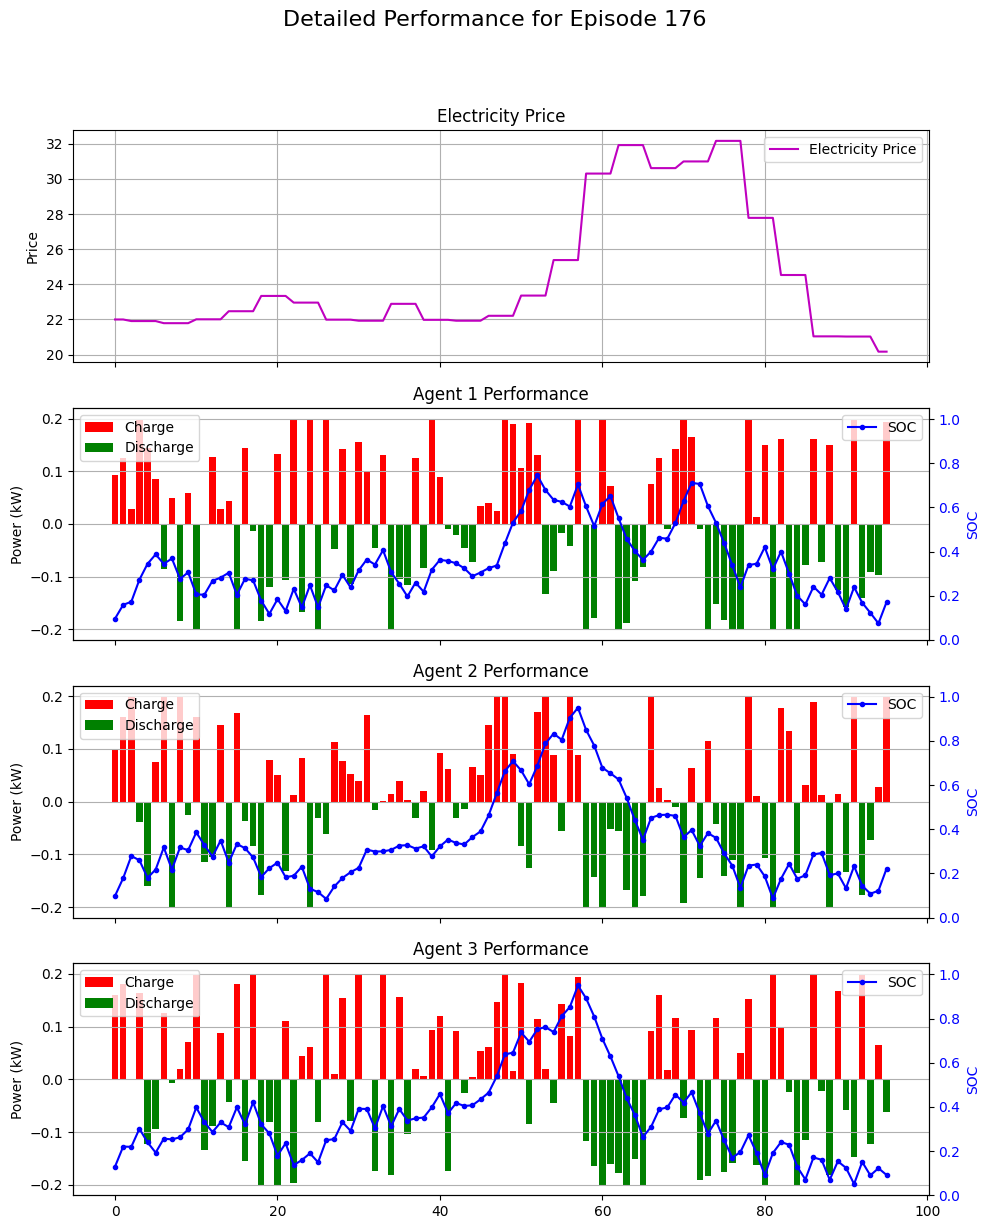

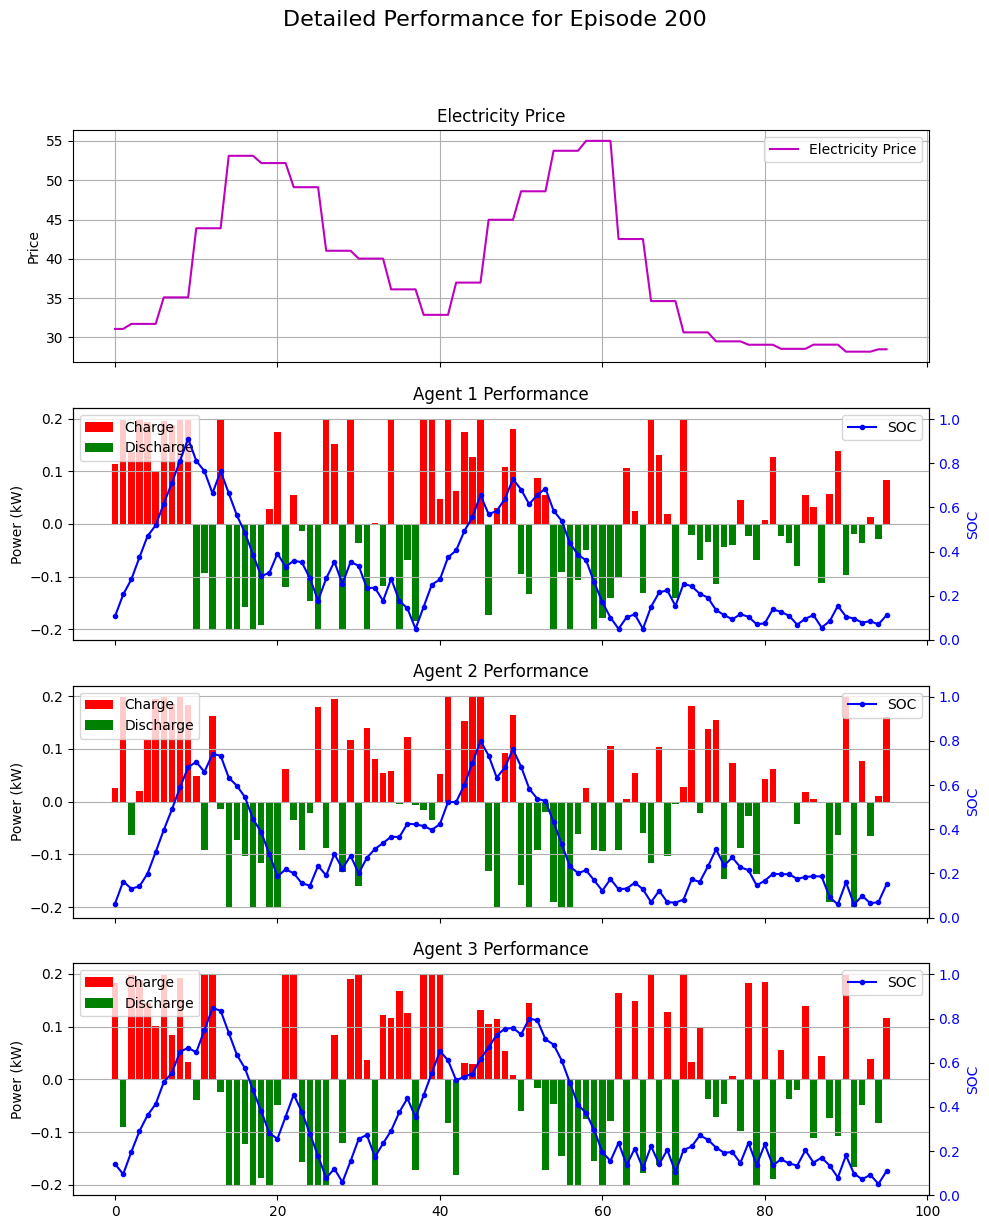

In [9]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import pandas as pd

# --- 1. 绘制奖励曲线 ---
print("--- Plotting Reward Curve ---")
plt.figure(figsize=(10, 4))

# 绘制原始的每回合奖励
plt.plot(runner.episode_rewards, color='blue', alpha=0.3, label='Episode Reward')

# 绘制平滑后的奖励曲线以观察趋势
if len(runner.episode_rewards) > 10:
    smoothed_rewards = gaussian_filter1d(runner.episode_rewards, sigma=5)
    plt.plot(smoothed_rewards, color='blue', linewidth=2, label='Smoothed Reward (sigma=5)')

# 计算并绘制移动平均奖励
if len(runner.episode_rewards) >= 20:
    moving_avg = pd.Series(runner.episode_rewards).rolling(window=20).mean()
    plt.plot(moving_avg, color='red', linewidth=2, label='Moving Average (20 episodes)')

plt.title(f'Training Rewards for {env_name}')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.savefig(f"reward_curve_{env_name}.png")
plt.show()


# --- 2. 可视化指定多个训练回合的数据 ---

# ===============================================================
# == 在这里设置你想可视化的回合数列表 (从0开始计数) ==
# == 例如 [0, 9, 99] 会打印第1, 10, 100回合 ==
episodes_to_plot = [0, 20, 50,100,150,175,199] 
# ===============================================================

print(f"\n--- Plotting Detailed Results for Episodes: {[e + 1 for e in episodes_to_plot]} ---")

# 循环遍历需要打印的每一代
for episode_idx in episodes_to_plot:
    if episode_idx >= len(runner.history) or episode_idx < 0:
        print(f"Warning: Episode {episode_idx + 1} not found. Skipping. (Total episodes trained: {len(runner.history)})")
        continue  # 如果指定的回合不存在，则跳过

    # 从历史记录中获取指定回合的数据
    episode_data = runner.history[episode_idx]
    price_history = episode_data['price']
    actions_history = episode_data['actions']
    soc_history = episode_data['soc']

    # 为当前回合创建一个新的图表
    fig, axs = plt.subplots(args.N + 1, 1, figsize=(10, 3 * (args.N + 1)), sharex=True)
    if args.N == 0:
        axs = [axs] # 保证在N=1时axs也是列表

    # 在图表最上方添加总标题
    fig.suptitle(f'Detailed Performance for Episode {episode_idx + 1}', fontsize=16, y=1.02)

    time_steps = np.arange(len(price_history))

    # 绘制电价子图
    ax_price = axs[0]
    ax_price.plot(time_steps, price_history, 'm-', label='Electricity Price')
    ax_price.set_ylabel('Price')
    ax_price.set_title(f'Electricity Price') # 子标题不再需要回合数
    ax_price.legend()
    ax_price.grid(True)

    # 循环绘制每个智能体的子图
    for i in range(args.N):
        ax1 = axs[i + 1]
        
        # 绘制充放电柱状图
        charge_power = np.array(actions_history[i])
        ax1.bar(time_steps, np.maximum(0, charge_power), color='r', width=0.8, label='Charge')
        ax1.bar(time_steps, np.minimum(0, charge_power), color='g', width=0.8, label='Discharge')
        ax1.set_ylabel('Power (kW)', color='k')
        ax1.set_title(f'Agent {i+1} Performance') # 子标题不再需要回合数
        ax1.legend(loc='upper left')
        ax1.grid(True, axis='y')

        # 创建第二个Y轴用于绘制SOC
        ax2 = ax1.twinx()
        ax2.plot(time_steps, soc_history[i][1:], 'b-', marker='.', label='SOC')
        ax2.set_ylabel('SOC', color='b')
        ax2.tick_params(axis='y', labelcolor='b')
        ax2.set_ylim(0, 1.05)
        ax2.legend(loc='upper right')

    # 设置共享的X轴标签并显示图表
    plt.xlabel('Time Step')
    fig.tight_layout(rect=[0, 0, 1, 0.98]) # 调整布局以适应总标题
    plt.show()


--- Plotting Electricity Price for the First 10 Days ---


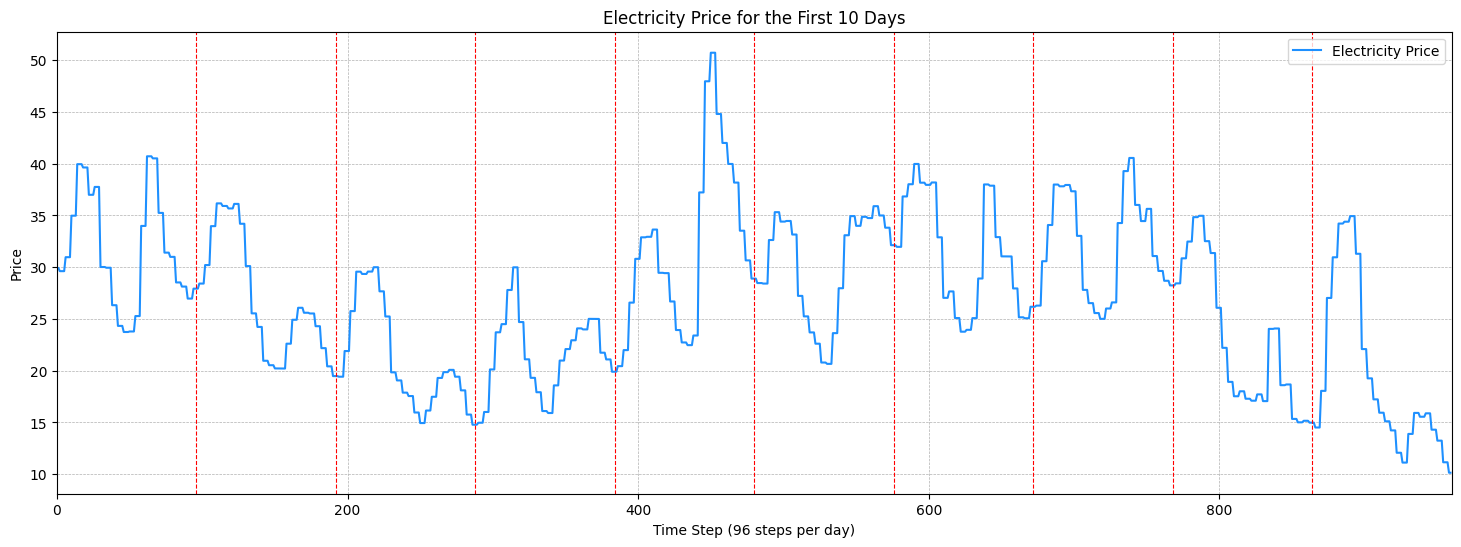

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 绘制前10天的电价图 ---
print("\n--- Plotting Electricity Price for the First 10 Days ---")

# 从环境中获取原始数据
# runner.env 是在之前单元格中创建的 EnergyStorageEnv 实例
raw_data = runner.env.raw_data
all_prices = raw_data.iloc[:, -1].values

# 定义要绘制的天数和每天的时段数
days_to_plot = 10
steps_per_day = 96  # 每天96个时段
total_steps_to_plot = days_to_plot * steps_per_day

# 检查数据是否足够长
if len(all_prices) < total_steps_to_plot:
    print(f"Warning: Data only contains {len(all_prices)} steps, which is less than the required {total_steps_to_plot} steps for {days_to_plot} days.")
    prices_to_plot = all_prices
else:
    prices_to_plot = all_prices[:total_steps_to_plot]

# 创建时间轴
time_axis = np.arange(len(prices_to_plot))

# 开始绘图
plt.figure(figsize=(18, 6))
plt.plot(time_axis, prices_to_plot, label='Electricity Price', color='dodgerblue')

# 添加垂直线来分隔每一天
for day in range(1, days_to_plot):
    plt.axvline(x=day * steps_per_day, color='red', linestyle='--', linewidth=0.8)

plt.title(f'Electricity Price for the First {days_to_plot} Days')
plt.xlabel(f'Time Step ({steps_per_day} steps per day)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(0, len(prices_to_plot))
plt.show()